# 08. Demo dự đoán Churn cho khách hàng mới

Notebook này minh họa cách sử dụng mô hình tốt nhất đã lưu để dự đoán nguy cơ rời bỏ dịch vụ cho khách hàng mới.

Mục tiêu demo:
- Tái sử dụng pipeline tiền xử lý đã xây dựng trong `src/`.
- Load mô hình tốt nhất từ `models/trained_models/best_model.pkl`.
- Dự đoán nhãn `Churn` và xác suất churn cho một vài khách hàng giả định.
- Rút ra gợi ý hành động giữ chân khách hàng.

In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DEFAULT_ROOT = Path(r"C:\\vscode\\hoctap\\Customer-Churn-Analysis")

def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents, DEFAULT_ROOT]:
        if (candidate / "src").exists() and (candidate / "configs").exists():
            return candidate
    raise FileNotFoundError("Không tìm thấy project root.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_data import load_dataset
from src.data.preprocess import preprocess_pipeline, transform_new_customers
from src.utils.config import load_project_config

sns.set_theme(style="whitegrid")
PROJECT_ROOT

WindowsPath('C:/vscode/hoctap/Customer-Churn-Analysis')

## 1. Load dữ liệu gốc, pipeline và mô hình tốt nhất

Vì notebook demo cần xử lý khách hàng mới đúng như dữ liệu train, ta nạp lại dữ liệu gốc để tái tạo encoder và scaler. Sau đó load mô hình tốt nhất đã lưu.

In [2]:
config = load_project_config(PROJECT_ROOT / "configs" / "config.yaml")
df_raw = load_dataset(PROJECT_ROOT / config["paths"]["raw_data"])
bundle = preprocess_pipeline(df_raw, config)

selected_features_path = PROJECT_ROOT / "models" / "metrics" / "selected_features.csv"
selected_features = pd.read_csv(selected_features_path)["feature"].tolist()

model_path = PROJECT_ROOT / "models" / "trained_models" / config["artifacts"]["best_model_file"]
model = joblib.load(model_path)

print("Best model path:", model_path)
print("Selected features:", selected_features)

Best model path: C:\vscode\hoctap\Customer-Churn-Analysis\models\trained_models\best_model.pkl
Selected features: ['tenure', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


## 2. Tạo hai khách hàng giả định

Ta tạo hai hồ sơ khách hàng để demo:
- Khách hàng nguy cơ cao: hợp đồng theo tháng, tenure thấp, chi phí tháng cao, không có OnlineSecurity và TechSupport.
- Khách hàng nguy cơ thấp: hợp đồng hai năm, tenure cao, có các dịch vụ hỗ trợ, phương thức thanh toán ổn định.

In [3]:
demo_customers = pd.DataFrame([
    {
        "customerID": "HIGH-RISK-001",
        "gender": "Female",
        "SeniorCitizen": 0,
        "Partner": "No",
        "Dependents": "No",
        "tenure": 2,
        "PhoneService": "Yes",
        "MultipleLines": "No",
        "InternetService": "Fiber optic",
        "OnlineSecurity": "No",
        "OnlineBackup": "No",
        "DeviceProtection": "No",
        "TechSupport": "No",
        "StreamingTV": "Yes",
        "StreamingMovies": "Yes",
        "Contract": "Month-to-month",
        "PaperlessBilling": "Yes",
        "PaymentMethod": "Electronic check",
        "MonthlyCharges": 95.0,
        "TotalCharges": 190.0,
    },
    {
        "customerID": "LOW-RISK-001",
        "gender": "Male",
        "SeniorCitizen": 0,
        "Partner": "Yes",
        "Dependents": "Yes",
        "tenure": 60,
        "PhoneService": "Yes",
        "MultipleLines": "Yes",
        "InternetService": "DSL",
        "OnlineSecurity": "Yes",
        "OnlineBackup": "Yes",
        "DeviceProtection": "Yes",
        "TechSupport": "Yes",
        "StreamingTV": "No",
        "StreamingMovies": "No",
        "Contract": "Two year",
        "PaperlessBilling": "No",
        "PaymentMethod": "Bank transfer (automatic)",
        "MonthlyCharges": 55.0,
        "TotalCharges": 3300.0,
    },
])

demo_customers

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,HIGH-RISK-001,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.0,190.0
1,LOW-RISK-001,Male,0,Yes,Yes,60,Yes,Yes,DSL,Yes,Yes,Yes,Yes,No,No,Two year,No,Bank transfer (automatic),55.0,3300.0


## 3. Dự đoán Churn bằng XGBoost

Khách hàng mới được đưa qua cùng encoder, scaler và danh sách selected features như mô hình đã dùng khi đánh giá chính thức.

In [4]:
X_demo = transform_new_customers(demo_customers, bundle)
X_demo_selected = X_demo[selected_features]

churn_probability = model.predict_proba(X_demo_selected)[:, 1]
predicted_encoded = model.predict(X_demo_selected).astype(int)
predicted_label = bundle.encoders[bundle.target_column].inverse_transform(predicted_encoded)

demo_result = demo_customers[[
    "customerID",
    "Contract",
    "tenure",
    "MonthlyCharges",
    "OnlineSecurity",
    "TechSupport",
    "PaymentMethod",
]].copy()
demo_result["churn_probability"] = churn_probability
demo_result["prediction"] = predicted_label
demo_result["risk_level"] = demo_result["churn_probability"].apply(
    lambda value: "Cao" if value >= 0.5 else "Thấp"
)
demo_result["suggested_action"] = demo_result["prediction"].map({
    "Yes": "Ưu tiên chăm sóc, tư vấn gói dài hạn và dịch vụ hỗ trợ",
    "No": "Duy trì chăm sóc định kỳ",
})

demo_result

,customerID,Contract,tenure,MonthlyCharges,OnlineSecurity,TechSupport,PaymentMethod,churn_probability,prediction,risk_level,suggested_action
0,HIGH-RISK-001,Month-to-month,2,95.0,No,No,Electronic check,0.941835,Yes,Cao,"Ưu tiên chăm sóc, tư vấn gói dài hạn và dịch v..."
1,LOW-RISK-001,Two year,60,55.0,Yes,Yes,Bank transfer (automatic),0.015204,No,Thấp,Duy trì chăm sóc định kỳ


## 4. Trực quan hóa kết quả demo

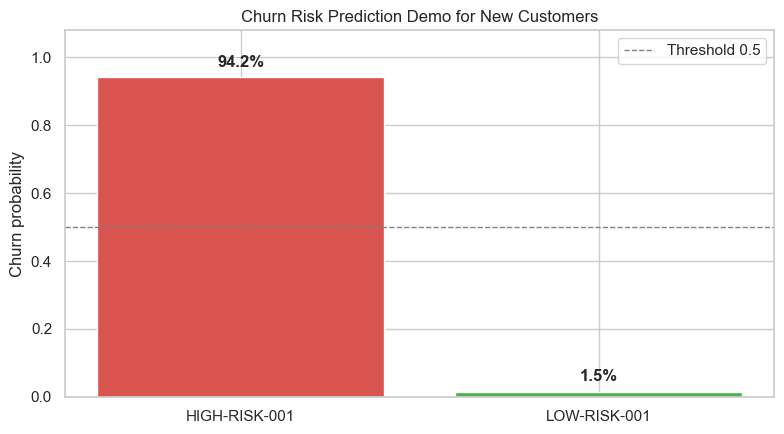

Saved figure: C:\vscode\hoctap\Customer-Churn-Analysis\reports\figures\customer_prediction_demo.png


In [5]:
figure_path = PROJECT_ROOT / "reports" / "figures" / "customer_prediction_demo.png"

plt.figure(figsize=(8, 4.5))
colors = ["#d9534f" if value >= 0.5 else "#4caf50" for value in demo_result["churn_probability"]]
bars = plt.bar(demo_result["customerID"], demo_result["churn_probability"], color=colors)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Threshold 0.5")
plt.ylim(0, 1.08)
plt.ylabel("Churn probability")
plt.title("Churn Risk Prediction Demo for New Customers")

for bar, value in zip(bars, demo_result["churn_probability"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.03,
        f"{value:.1%}",
        ha="center",
        fontweight="bold",
    )

plt.legend()
plt.tight_layout()
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)

## 5. Nhận xét dùng cho slide

Khách hàng `HIGH-RISK-001` có nhiều đặc điểm từng được EDA và Feature Importance chỉ ra là rủi ro cao: hợp đồng theo tháng, thời gian sử dụng ngắn, chi phí hàng tháng cao, không có `OnlineSecurity`, không có `TechSupport` và thanh toán bằng `Electronic check`. Vì vậy mô hình dự đoán khách hàng này có nguy cơ churn cao.

Khách hàng `LOW-RISK-001` có hợp đồng hai năm, thời gian sử dụng dài và có các dịch vụ hỗ trợ quan trọng, nên mô hình dự đoán nguy cơ churn thấp.

Câu nói khi thuyết trình:

> Để minh họa khả năng ứng dụng thực tế, nhóm em thử nhập thông tin hai khách hàng mới vào pipeline. Mô hình XGBoost trả về xác suất churn cho từng khách hàng. Với khách hàng có hợp đồng tháng, tenure thấp, chi phí cao và thiếu dịch vụ hỗ trợ, mô hình cảnh báo nguy cơ churn cao. Kết quả này cho thấy mô hình có thể hỗ trợ doanh nghiệp ưu tiên chăm sóc đúng nhóm khách hàng cần giữ chân.